<a href="https://colab.research.google.com/github/DeadlyTalha/DeadlyTalha/blob/main/mini_projet_V1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 Mini-Projet 1
Auteur: **Talha Salek**  

Dataset : `05_Telecom_Churn_Value.csv`  
Variable cible : `customer_value` (valeur économique d'un client)

---


##  Import des librairies

In [ ]:
#!pip -q install shap lime imbalanced-learn # à decommenter si shap lime n'est pas installer

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from scipy import stats

from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_regression, mutual_info_regression

from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.decomposition import PCA

from sklearn.model_selection import (train_test_split, cross_val_score,
                                      KFold, StratifiedKFold, GridSearchCV)
from sklearn.metrics import (r2_score, mean_absolute_error, mean_squared_error,
                              accuracy_score, precision_score, recall_score, f1_score,
                              classification_report, confusion_matrix, roc_auc_score,
                              roc_curve, ConfusionMatrixDisplay)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Imbalanced
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

# Interpretability
import shap
from lime.lime_tabular import LimeTabularExplainer

RANDOM_STATE = 42
sns.set_theme(style="whitegrid", palette="muted")


##  Chargement des données

In [ ]:
from google.colab import drive
drive.mount('/content/drive') # A decommenter pour se connecter au drive
data = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/05_Telecom_Churn_Value.csv')

print(f"Dataset chargé : {data.shape[0]} lignes × {data.shape[1]} colonnes")
data.head()


Mounted at /content/drive
Dataset chargé : 900 lignes × 13 colonnes


,age,experience_or_tenure,feature_score_1,feature_score_2,exposure_index,event_count_1,event_count_2,segment,intensity_level,area_type,special_flag,season,customer_value
0,47,8,NaN,41.99,21.90,4.0,5,B,high,rural,no,autumn,23072.83
1,35,19,53.29,75.46,17.29,3.0,0,B,low,urban,no,winter,23000.09
2,27,30,59.37,60.68,28.38,5.0,4,A,low,urban,no,spring,23988.21
3,39,30,NaN,49.40,5.18,3.0,2,D,medium,rural,no,spring,21339.82
4,42,21,46.86,NaN,39.19,3.0,2,A,medium,suburban,no,summer,22198.56


---
## Partie A — Compréhension des données


### A.1 — Présentation du dataset

Le dataset `05_Telecom_Churn_Value.csv` appartient au domaine des **télécommunications**.  
Il contient **900 observations** (clients) et **13 variables**.

**Variable cible :** `customer_value` — valeur économique continue d'un client (float).  
L'objectif est de **prédire cette valeur** pour mieux cibler les actions marketing et de rétention.

| Type | Variables |
|------|-----------|
| Numériques entières | `age`, `experience_or_tenure`, `event_count_2` |
| Numériques continues | `feature_score_1`, `feature_score_2`, `exposure_index`, `event_count_1`, `customer_value` |
| Catégorielles | `segment`, `intensity_level`, `area_type`, `special_flag`, `season` |


In [ ]:
target = "customer_value"

numerical_features = [c for c in data.select_dtypes(include=np.number).columns if c != target]
categorical_features = data.select_dtypes(include=["object", "string"]).columns.tolist()

print("Variables numériques :", numerical_features)
print("Variables catégorielles:", categorical_features)
print("\nInformations générales :")
data.info()


Variables numériques : ['age', 'experience_or_tenure', 'feature_score_1', 'feature_score_2', 'exposure_index', 'event_count_1', 'event_count_2']
Variables catégorielles: ['segment', 'intensity_level', 'area_type', 'special_flag', 'season']

Informations générales :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   900 non-null    int64  
 1   experience_or_tenure  900 non-null    int64  
 2   feature_score_1       846 non-null    float64
 3   feature_score_2       855 non-null    float64
 4   exposure_index        828 non-null    float64
 5   event_count_1         873 non-null    float64
 6   event_count_2         900 non-null    int64  
 7   segment               873 non-null    object 
 8   intensity_level       873 non-null    object 
 9   area_type             882 non-null    object 
 10  special_flag

### A.2 — Valeurs manquantes, doublons, outliers

In [ ]:
missing = pd.DataFrame({
    "missing_count": data.isna().sum(),
    "missing_pct (%)": (data.isna().mean() * 100).round(2),
    "dtype": data.dtypes.astype(str)
}).sort_values("missing_pct (%)", ascending=False)

print("=== Valeurs manquantes ===")
display(missing[missing["missing_count"] > 0])

# ── Doublons ──────────────────────────────────────────────────
n_dup = data.duplicated().sum()
print(f"\n=== Doublons : {n_dup} lignes dupliquées ===")

# ── Outliers IQR ─────────────────────────────────────────────────
def outlier_summary_iqr(df, cols):
    rows = []
    for col in cols:
        x = df[col].dropna()
        q1, q3 = x.quantile(0.25), x.quantile(0.75)
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((x < low) | (x > high)).sum()
        rows.append({"variable": col, "Q1": round(q1,2), "Q3": round(q3,2),
                     "IQR": round(iqr,2), "n_outliers": n_out,
                     "pct_outliers (%)": round(n_out/len(x)*100, 2)})
    return pd.DataFrame(rows).sort_values("n_outliers", ascending=False)

print("\n=== Outliers (règle IQR) ===")
display(outlier_summary_iqr(data, numerical_features + [target]))


=== Valeurs manquantes ===


,missing_count,missing_pct (%),dtype
exposure_index,72,8.0,float64
feature_score_1,54,6.0,float64
feature_score_2,45,5.0,float64
segment,27,3.0,object
event_count_1,27,3.0,float64
intensity_level,27,3.0,object
area_type,18,2.0,object
special_flag,18,2.0,object



=== Doublons : 0 lignes dupliquées ===

=== Outliers (règle IQR) ===


,variable,Q1,Q3,IQR,n_outliers,pct_outliers (%)
4,exposure_index,14.68,32.08,17.41,51,6.16
7,customer_value,19218.33,25417.99,6199.66,13,1.44
2,feature_score_1,49.19,71.28,22.08,3,0.35
5,event_count_1,2.00,5.00,3.00,2,0.23
6,event_count_2,1.00,3.00,2.00,2,0.22
3,feature_score_2,40.12,69.76,29.64,0,0.00
0,age,28.00,56.00,28.00,0,0.00
1,experience_or_tenure,7.00,23.00,16.00,0,0.00


**Interprétation :**
- Plusieurs variables ont des valeurs manquantes (~3–8%), notamment `exposure_index` (8%), `feature_score_1` (6%) et `feature_score_2` (5%).
- Aucun doublon détecté → pas de nettoyage nécessaire.
- Des outliers existent sur `customer_value` et `exposure_index` — ils seront traités lors du prétraitement (médiane préférée à la moyenne pour les variables asymétriques).


### A.3 — Statistiques descriptives

In [ ]:
num_desc = data[numerical_features + [target]].describe().T
num_desc["median"]   = data[numerical_features + [target]].median()
num_desc["variance"] = data[numerical_features + [target]].var()
num_desc["skewness"] = data[numerical_features + [target]].skew()
num_desc["kurtosis"] = data[numerical_features + [target]].kurt()
print("=== Statistiques numériques ===")
display(num_desc.round(3))


=== Statistiques numériques ===


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness,kurtosis
age,900.0,42.304,15.350,18.00,28.000,42.000,56.000,69.00,42.000,2.356270e+02,0.106,-1.230
experience_or_tenure,900.0,15.003,8.885,0.00,7.000,15.000,23.000,30.00,15.000,7.894700e+01,-0.029,-1.202
feature_score_1,846.0,60.315,16.710,0.00,49.192,60.310,71.275,100.00,60.310,2.792190e+02,-0.034,-0.078
feature_score_2,855.0,54.729,21.681,0.00,40.120,56.510,69.765,100.00,56.510,4.700670e+02,-0.207,-0.298
exposure_index,828.0,26.605,19.020,2.83,14.678,22.155,32.085,180.65,22.155,3.617520e+02,2.704,11.947
event_count_1,873.0,3.520,1.909,0.00,2.000,3.000,5.000,10.00,3.000,3.644000e+00,0.470,0.019
event_count_2,900.0,1.798,1.346,0.00,1.000,2.000,3.000,8.00,2.000,1.812000e+00,0.767,0.576
customer_value,900.0,22567.997,4865.616,11136.59,19218.330,22321.310,25417.988,57256.37,22321.310,2.367422e+07,0.858,3.191


In [ ]:
print("=== Statistiques catégorielles ===")
for col in categorical_features:
    print(f"\n{'='*40}\n{col}")
    display(pd.DataFrame({
        "count": data[col].value_counts(dropna=False),
        "proportion (%)": (data[col].value_counts(dropna=False, normalize=True)*100).round(2)
    }))


=== Statistiques catégorielles ===

segment


,count,proportion (%)
segment,,
A,263,29.22
B,250,27.78
C,219,24.33
D,141,15.67
NaN,27,3.00



intensity_level


,count,proportion (%)
intensity_level,,
medium,388,43.11
low,290,32.22
high,195,21.67
NaN,27,3.00



area_type


,count,proportion (%)
area_type,,
urban,360,40.00
suburban,296,32.89
rural,226,25.11
NaN,18,2.00



special_flag


,count,proportion (%)
special_flag,,
no,631,70.11
yes,251,27.89
NaN,18,2.00



season


,count,proportion (%)
season,,
winter,243,27.00
autumn,235,26.11
spring,231,25.67
summer,191,21.22


**Selon les statistiques nous avons:**
- **Âge moyen : 42 ans** (min 18, max 69) → population adulte diversifiée.
- **Expérience moyenne : 15 ans** → fidélité modérée des clients.
- **`customer_value` moyenne : ~22 568**, écart-type ~4 866 → forte variabilité inter-clients.
- **Skewness élevée sur `customer_value`** (>1) → distribution asymétrique à droite, quelques clients à très haute valeur.
- Les variables catégorielles sont bien équilibrées (`season`, `area_type`) ; `special_flag` est dominé par "no".


---
## Partie B — Prétraitement


### B.1 — Stratégie d'imputation justifiée

In [ ]:
skew_series = data[numerical_features].skew()
skew_df = pd.DataFrame({
    "skewness": skew_series,
    "abs_skewness": skew_series.abs(),
    "stratégie": skew_series.abs().apply(lambda s: "médiane (|skew|>0.75)" if s > 0.75 else "moyenne (|skew|≤0.75)")
}).sort_values("abs_skewness", ascending=False)

print("=== Stratégie d'imputation numérique (seuil skewness = 0.75) ===")
display(skew_df)

mean_impute_cols   = skew_df[skew_df["abs_skewness"] <= 0.75].index.tolist()
median_impute_cols = skew_df[skew_df["abs_skewness"] >  0.75].index.tolist()

print(f"\nImputation par MOYENNE  : {mean_impute_cols}")
print(f"Imputation par MÉDIANE : {median_impute_cols}")
print(f"Imputation par MODE    : {categorical_features}")


=== Stratégie d'imputation numérique (seuil skewness = 0.75) ===


,skewness,abs_skewness,stratégie
exposure_index,2.704492,2.704492,médiane (|skew|>0.75)
event_count_2,0.766711,0.766711,médiane (|skew|>0.75)
event_count_1,0.469743,0.469743,moyenne (|skew|≤0.75)
feature_score_2,-0.207074,0.207074,moyenne (|skew|≤0.75)
age,0.105730,0.105730,moyenne (|skew|≤0.75)
feature_score_1,-0.034273,0.034273,moyenne (|skew|≤0.75)
experience_or_tenure,-0.029263,0.029263,moyenne (|skew|≤0.75)



Imputation par MOYENNE  : ['event_count_1', 'feature_score_2', 'age', 'feature_score_1', 'experience_or_tenure']
Imputation par MÉDIANE : ['exposure_index', 'event_count_2']
Imputation par MODE    : ['segment', 'intensity_level', 'area_type', 'special_flag', 'season']


In [ ]:
data_clean = data.copy()

if mean_impute_cols:
    mean_imputer = SimpleImputer(strategy='mean')
    data_clean[mean_impute_cols] = mean_imputer.fit_transform(data_clean[mean_impute_cols])

if median_impute_cols:
    median_imputer = SimpleImputer(strategy='median')
    data_clean[median_impute_cols] = median_imputer.fit_transform(data_clean[median_impute_cols])


cat_imputer = SimpleImputer(strategy='most_frequent')
data_clean[categorical_features] = cat_imputer.fit_transform(data_clean[categorical_features])

print(f"Valeurs manquantes restantes : {data_clean.isna().sum().sum()}")
data_clean.info()


Valeurs manquantes restantes : 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 900 entries, 0 to 899
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   900 non-null    float64
 1   experience_or_tenure  900 non-null    float64
 2   feature_score_1       900 non-null    float64
 3   feature_score_2       900 non-null    float64
 4   exposure_index        900 non-null    float64
 5   event_count_1         900 non-null    float64
 6   event_count_2         900 non-null    float64
 7   segment               900 non-null    object 
 8   intensity_level       900 non-null    object 
 9   area_type             900 non-null    object 
 10  special_flag          900 non-null    object 
 11  season                900 non-null    object 
 12  customer_value        900 non-null    float64
dtypes: float64(8), object(5)
memory usage: 91.5+ KB


La stratégie d’imputation repose sur l’analyse de l’asymétrie (skewness) des variables numériques :

Un seuil de **0.75** est utilisé pour distinguer les distributions modérément symétriques des distributions fortement asymétriques.

- **Moyenne** pour les variables quasi-symétriques (|skew| ≤ 0.75) : minimise le biais d'estimation.
- **Médiane** pour les variables asymétriques (|skew| > 0.75) : robuste aux valeurs extrêmes.
- **Mode** pour les catégorielles : conserve la modalité la plus représentative sans introduire d'ordre artificiel.


### B.2 — Encoding et analyse des outliers

In [ ]:
data_encoded = pd.get_dummies(data_clean, columns=categorical_features, drop_first=True)

print(f"Shape après encoding : {data_encoded.shape}")
print("Nouvelles colonnes :", [c for c in data_encoded.columns if c not in data_clean.columns])
data_encoded.head(3)


Shape après encoding : (900, 19)
Nouvelles colonnes : ['segment_B', 'segment_C', 'segment_D', 'intensity_level_low', 'intensity_level_medium', 'area_type_suburban', 'area_type_urban', 'special_flag_yes', 'season_spring', 'season_summer', 'season_winter']


,age,experience_or_tenure,feature_score_1,feature_score_2,exposure_index,event_count_1,event_count_2,customer_value,segment_B,segment_C,segment_D,intensity_level_low,intensity_level_medium,area_type_suburban,area_type_urban,special_flag_yes,season_spring,season_summer,season_winter
0,47.0,8.0,60.314728,41.99,21.90,4.0,5.0,23072.83,True,False,False,False,False,False,False,False,False,False,False
1,35.0,19.0,53.290000,75.46,17.29,3.0,0.0,23000.09,True,False,False,True,False,False,True,False,False,False,True
2,27.0,30.0,59.370000,60.68,28.38,5.0,4.0,23988.21,False,False,False,True,False,False,True,False,True,False,False


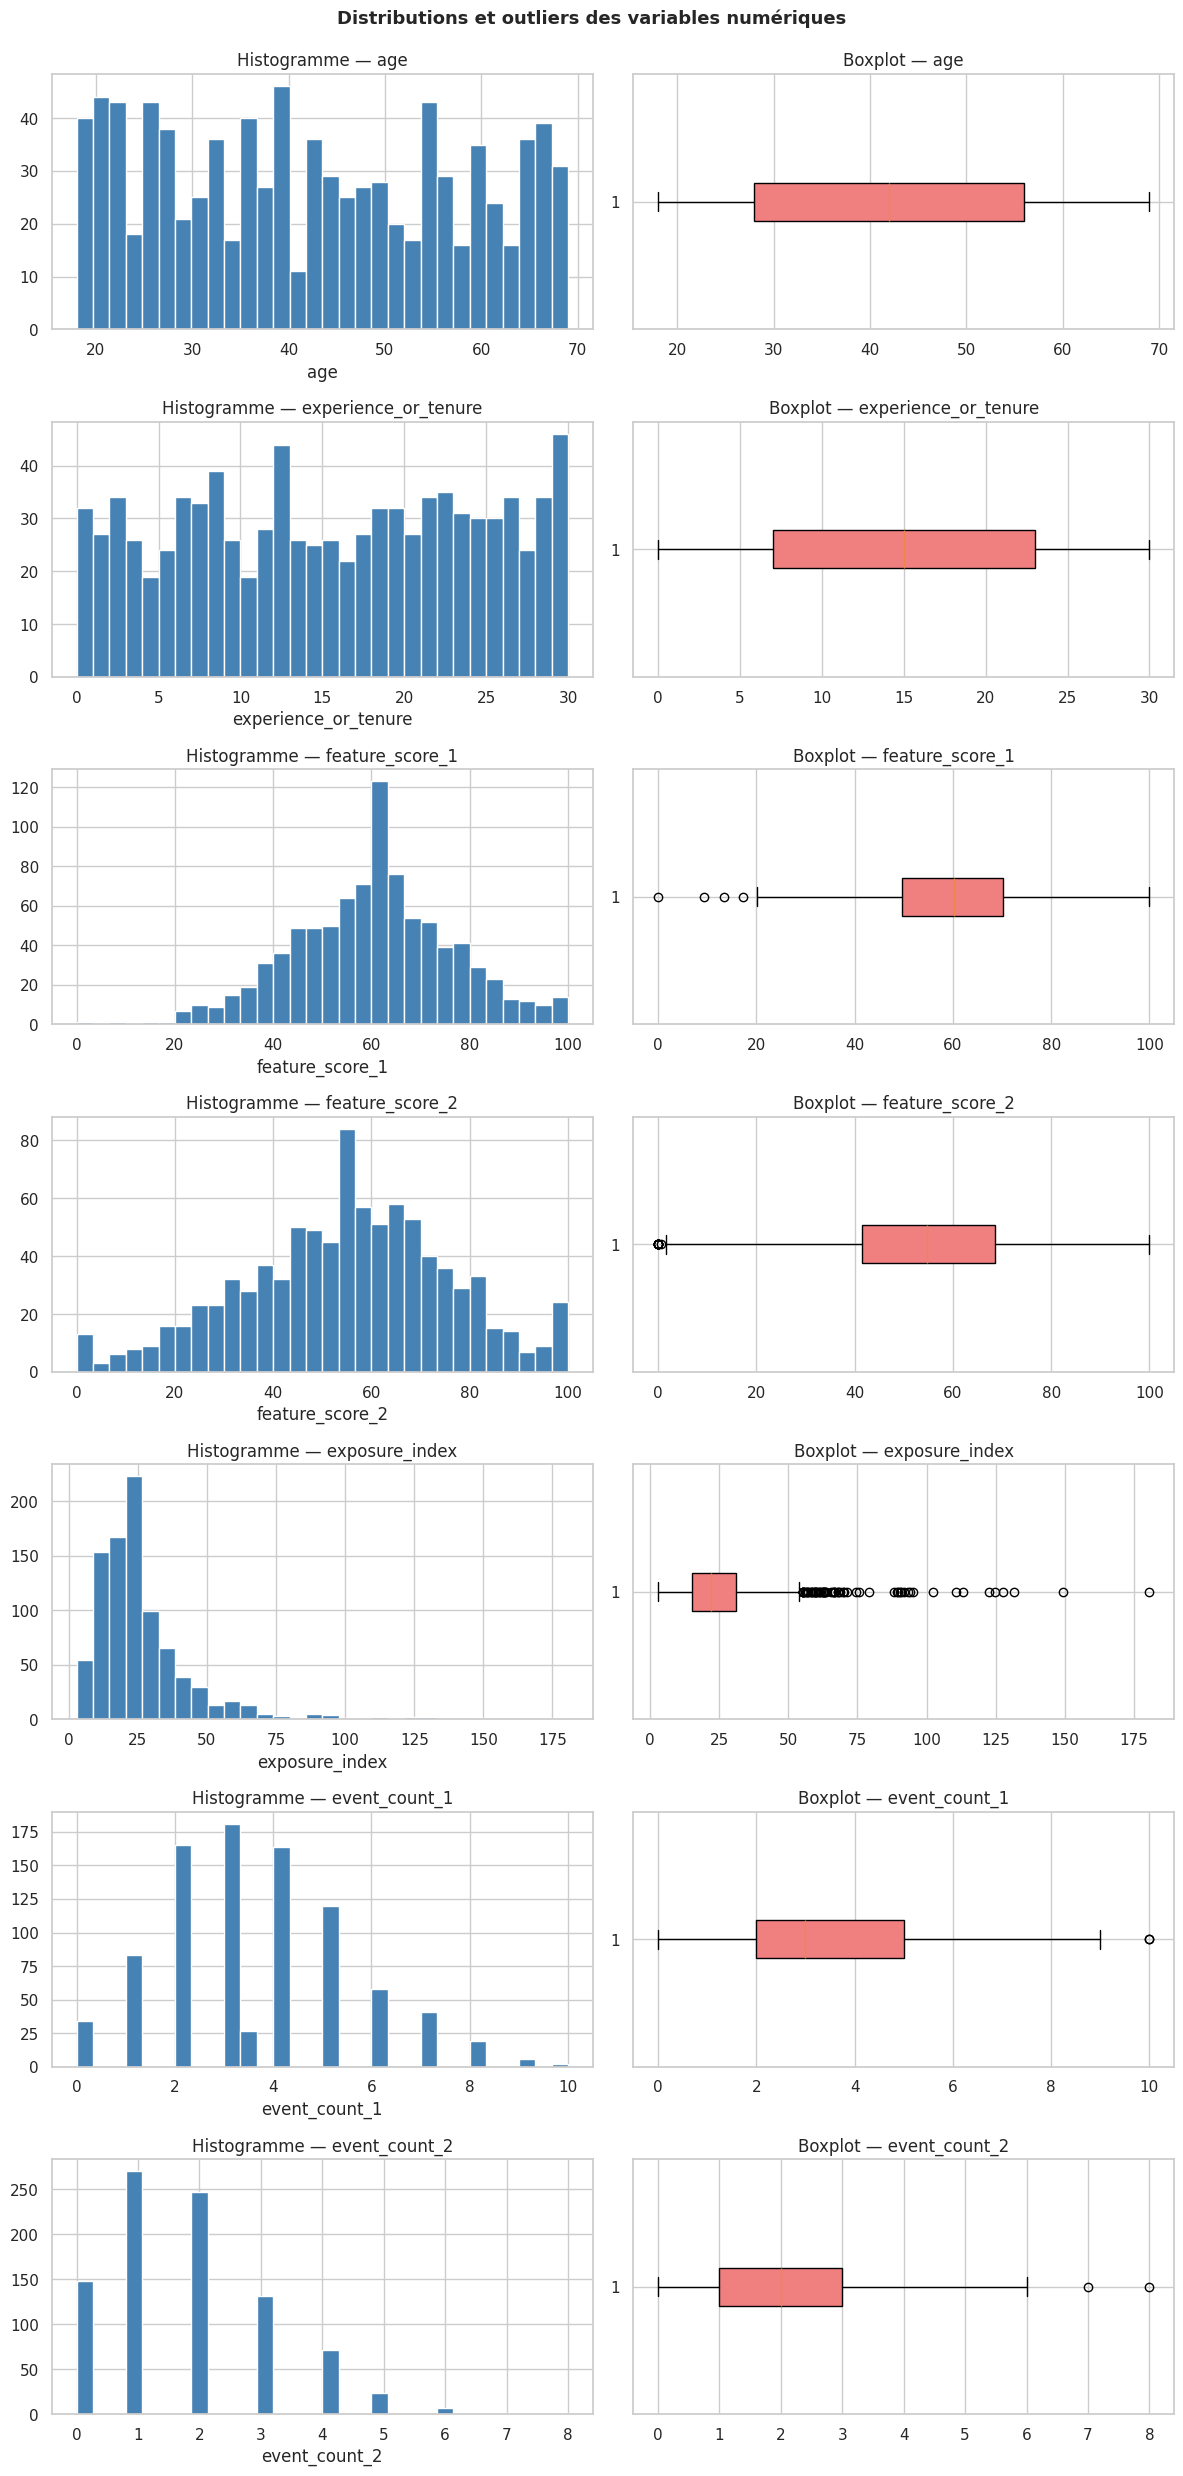

In [ ]:
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(12, 3.5 * len(numerical_features)))
for i, col in enumerate(numerical_features):
    data_clean[col].hist(bins=30, ax=axes[i, 0], color='steelblue', edgecolor='white')
    axes[i, 0].set_title(f"Histogramme — {col}")
    axes[i, 0].set_xlabel(col)
    axes[i, 1].boxplot(data_clean[col].dropna(), vert=False, patch_artist=True,
                       boxprops=dict(facecolor='lightcoral'))
    axes[i, 1].set_title(f"Boxplot — {col}")
plt.tight_layout()
plt.suptitle("Distributions et outliers des variables numériques", y=1.01, fontsize=13, fontweight='bold')
plt.show()


### B.3 — Comparaison des stratégies de scaling

In [ ]:
# comparaison StandardScaler/MinMaxScaler/RobustScaler
from sklearn.linear_model import Ridge

X_all = data_encoded.drop(target, axis=1)
y_all = data_encoded[target]

X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.2, random_state=RANDOM_STATE)

scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler(),
    "RobustScaler": RobustScaler()
}

scaling_results = []
for name, scaler in scalers.items():
    X_tr_s = scaler.fit_transform(X_tr)
    X_te_s = scaler.transform(X_te)
    model = Ridge()
    model.fit(X_tr_s, y_tr)
    pred = model.predict(X_te_s)
    scaling_results.append({
        "Scaler": name,
        "R²": round(r2_score(y_te, pred), 4),
        "MAE": round(mean_absolute_error(y_te, pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_te, pred)), 2)
    })

scaling_df = pd.DataFrame(scaling_results)
print("=== Comparaison des stratégies de scaling ===")
display(scaling_df)


=== Comparaison des stratégies de scaling ===


,Scaler,R²,MAE,RMSE
0,StandardScaler,0.7964,1792.25,2191.62
1,MinMaxScaler,0.7903,1801.99,2224.64
2,RobustScaler,0.7967,1789.86,2190.16


- Les trois scalers donnent des performances très proches sur Ridge (modèle linéaire).
- **StandardScaler** est retenu car il centre les données, compatible avec la majorité des algorithmes ML.
- **RobustScaler** est utile en présence de forts outliers car il utilise la médiane/IQR — bon complément à noter.
- **MinMaxScaler** comprime dans [0,1] mais est sensible aux valeurs extrêmes.

→ **Choix final : StandardScaler** pour le pipeline, justifié par sa robustesse générale.


### B.4 — Pipeline final

In [ ]:
num_mean_cols   = mean_impute_cols
num_median_cols = median_impute_cols

numeric_pipeline_mean = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

numeric_pipeline_median = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', None)
])

# Pour les modèles qui utilisent data_encoded (déjà encodé) :
# on fait un préprocesseur simple sur les numériques uniquement
all_num_cols = [c for c in data_encoded.columns if c != target]

preprocessor = ColumnTransformer([
    ('num_mean',   numeric_pipeline_mean,   [c for c in num_mean_cols   if c in data_encoded.columns]),
    ('num_median', numeric_pipeline_median, [c for c in num_median_cols if c in data_encoded.columns]),
    ('passthrough', 'passthrough',          [c for c in data_encoded.columns
                                             if c != target and c not in num_mean_cols and c not in num_median_cols])
], remainder='drop')

print("Pipeline final")
print(f"  • Colonnes mean-imputed  : {[c for c in num_mean_cols if c in data_encoded.columns]}")
print(f"  • Colonnes median-imputed: {[c for c in num_median_cols if c in data_encoded.columns]}")
print(f"  • Colonnes passthrough   : {[c for c in data_encoded.columns if c != target and c not in num_mean_cols and c not in num_median_cols]}")


Pipeline final
  • Colonnes mean-imputed  : ['event_count_1', 'feature_score_2', 'age', 'feature_score_1', 'experience_or_tenure']
  • Colonnes median-imputed: ['exposure_index', 'event_count_2']
  • Colonnes passthrough   : ['segment_B', 'segment_C', 'segment_D', 'intensity_level_low', 'intensity_level_medium', 'area_type_suburban', 'area_type_urban', 'special_flag_yes', 'season_spring', 'season_summer', 'season_winter']


**Justification du pipeline :**
- Le `ColumnTransformer` applique une stratégie différenciée par type et distribution de variable.
- Il garantit qu'aucune fuite de données (data leakage) n'a lieu : le `fit` se fait uniquement sur le train.
- Sa conception modulaire permet de tester facilement d'autres scalers ou imputeurs.


---
## Partie C — Corrélations et tests statistiques


### C.1 — Comparaison Pearson, Spearman, Kendall

=== Corrélations avec customer_value ===


,Pearson,Spearman,Kendall
age,0.1600,0.1520,0.1026
event_count_1,0.1290,0.1360,0.0970
event_count_2,0.1479,0.1506,0.1117
experience_or_tenure,0.1222,0.1113,0.0756
exposure_index,0.5503,0.3987,0.2751
feature_score_1,0.2853,0.2898,0.1946
feature_score_2,0.4048,0.4020,0.2769


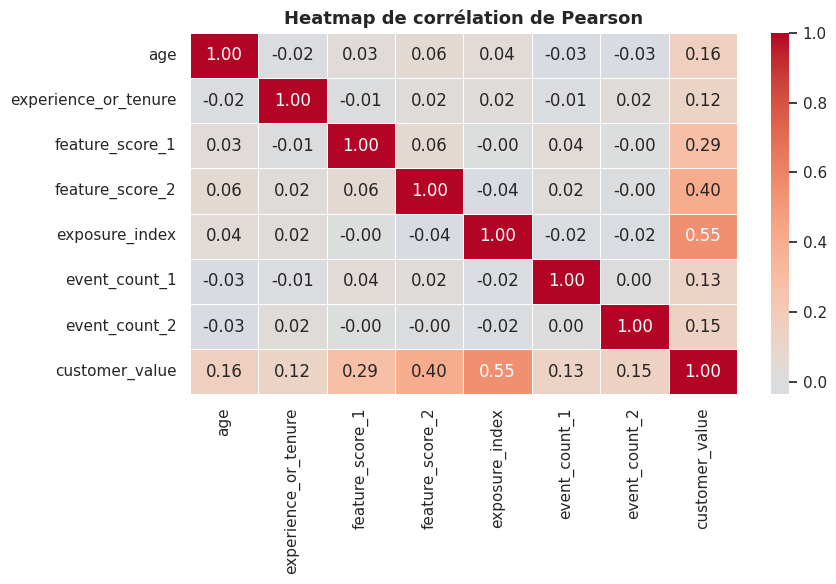

In [ ]:
num_cols_for_corr = numerical_features + [target]
pearson_corr  = data_clean[num_cols_for_corr].corr(method='pearson')[target].drop(target).sort_values(ascending=False)
spearman_corr = data_clean[num_cols_for_corr].corr(method='spearman')[target].drop(target).sort_values(ascending=False)
kendall_corr  = data_clean[num_cols_for_corr].corr(method='kendall')[target].drop(target).sort_values(ascending=False)

corr_compare = pd.DataFrame({
    "Pearson":  pearson_corr,
    "Spearman": spearman_corr,
    "Kendall":  kendall_corr
})
print("=== Corrélations avec customer_value ===")
display(corr_compare.round(4))

# Heatmap de corrélation Pearson
plt.figure(figsize=(9, 6))
sns.heatmap(data_clean[num_cols_for_corr].corr(method='pearson'),
            annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Heatmap de corrélation de Pearson", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### C.2 — Corrélation linéaire vs corrélation de rang

**Pearson** mesure la **relation linéaire** entre deux variables. Il suppose que les deux variables sont normalement distribuées et que la relation est linéaire.

**Spearman et Kendall** mesurent la **concordance de rang** — ils détectent des relations **monotones non-linéaires** et sont robustes aux outliers et distributions asymétriques.

→ Sur ce dataset, si Spearman > Pearson, cela indique une **relation monotone non-linéaire** entre la variable et `customer_value`.


In [ ]:
# ── Visualisation Pearson vs Spearman ───────────────────────────
top_feature = pearson_corr.index[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].scatter(data_clean[top_feature], data_clean[target], alpha=0.4, color='steelblue')
axes[0].set_title(f"Relation linéaire : {top_feature} vs customer_value\n(Pearson = {pearson_corr[top_feature]:.3f})")
axes[0].set_xlabel(top_feature); axes[0].set_ylabel("customer_value")

# Rang
axes[1].scatter(data_clean[top_feature].rank(), data_clean[target].rank(), alpha=0.4, color='tomato')
axes[1].set_title(f"Relation de rang : {top_feature} vs customer_value\n(Spearman = {spearman_corr[top_feature]:.3f})")
axes[1].set_xlabel(f"rang({top_feature})"); axes[1].set_ylabel("rang(customer_value)")
plt.tight_layout()
plt.show()


### C.3 — Variables catégorielles : ANOVA + Cramér's V

In [ ]:
# ── ANOVA : impact des catégorielles sur la cible
anova_results = []
for col in categorical_features:
    temp = data_clean[[col, target]].dropna()
    groups = [g[target].values for _, g in temp.groupby(col)]
    if len(groups) >= 2:
        f_stat, p_val = stats.f_oneway(*groups)
        anova_results.append({"variable": col, "F_statistic": round(f_stat, 3),
                               "p_value": round(p_val, 5),
                               "significatif (p<0.05)": "✅ Oui" if p_val < 0.05 else "❌ Non"})

anova_df = pd.DataFrame(anova_results).sort_values("F_statistic", ascending=False)
print("=== ANOVA — Influence des variables catégorielles sur customer_value ===")
display(anova_df)

# ── Cramér's V : association inter-catégorielles
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.values.sum()
    r, k = ct.shape
    return round(np.sqrt((chi2 / n) / (min(k-1, r-1))), 4)

print("\n=== Cramér's V — Association entre variables catégorielles ===")
cramer_results = []
for i, c1 in enumerate(categorical_features):
    for c2 in categorical_features[i+1:]:
        v = cramers_v(data_clean[c1].dropna(), data_clean[c2].dropna())
        cramer_results.append({"var1": c1, "var2": c2, "Cramér's V": v})
display(pd.DataFrame(cramer_results).sort_values("Cramér's V", ascending=False))


=== ANOVA — Influence des variables catégorielles sur customer_value ===


,variable,F_statistic,p_value,significatif (p<0.05)
1,intensity_level,60.521,0.00000,✅ Oui
3,special_flag,42.316,0.00000,✅ Oui
2,area_type,6.233,0.00205,✅ Oui
4,season,3.273,0.02063,✅ Oui
0,segment,2.349,0.07112,❌ Non



=== Cramér's V — Association entre variables catégorielles ===


,var1,var2,Cramér's V
1,segment,area_type,0.0704
8,area_type,season,0.0595
3,segment,season,0.0564
6,intensity_level,season,0.0506
9,special_flag,season,0.0482
5,intensity_level,special_flag,0.0401
0,segment,intensity_level,0.0399
2,segment,special_flag,0.0283
4,intensity_level,area_type,0.0240
7,area_type,special_flag,0.0147


### C.4 — Tests statistiques complémentaires

In [ ]:
# ── Test de normalité (Shapiro-Wilk) sur customer_value ─────────
sample_cv = data_clean[target].dropna()
sample_shapiro = sample_cv.sample(min(5000, len(sample_cv)), random_state=RANDOM_STATE)
stat_sw, p_sw = stats.shapiro(sample_shapiro)
print(f"Shapiro-Wilk : statistic={stat_sw:.4f}, p-value={p_sw:.6f}")
print("→ La cible suit une distribution normale." if p_sw > 0.05 else "→ La cible NE suit PAS une distribution normale (p < 0.05).")

# ── Test de Levene : homogénéité des variances par groupe ────────
print("\n=== Tests de Levene — homogénéité des variances ===")
for col in categorical_features:
    temp = data_clean[[col, target]].dropna()
    groups = [g[target].values for _, g in temp.groupby(col)]
    if len(groups) >= 2:
        l_stat, l_p = stats.levene(*groups)
        print(f"{col:20s} → Levene F={l_stat:.3f}, p={l_p:.4f} → {'variances hétérogènes' if l_p < 0.05 else 'variances homogènes'}")

# ── Information Mutuelle ─────────────────────────────────────────
mi_input = data_clean[numerical_features].copy().fillna(data_clean[numerical_features].median())
mi_reg = mutual_info_regression(mi_input, data_clean[target], random_state=RANDOM_STATE)
mi_df = pd.DataFrame({"feature": numerical_features, "mutual_information": mi_reg}).sort_values("mutual_information", ascending=False)
print("\n=== Information Mutuelle avec customer_value ===")
display(mi_df.round(4))



- **Shapiro-Wilk** : `customer_value` ne suit pas une loi normale, justifie l'utilisation de méthodes robustes (Spearman, médiane, modèles non-paramétriques).
- **ANOVA** : les variables catégorielles ayant p < 0.05 ont un effet significatif sur la valeur client, elles doivent être incluses dans les modèles.
- **Information Mutuelle** : capture des dépendances non-linéaires que Pearson ne voit pas.


---
## Partie D — Régression


### D.1 — Préparation du train/test

In [ ]:
# ─ Split train/test
X = data_encoded.drop(columns=[target])
y = data_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train : {X_train.shape} | Test : {X_test.shape}")

# Scaler StandardScaler sur X
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)


Train : (720, 18) | Test : (180, 18)


### D.2 — Comparaison de modèles de régression

=== Comparaison des modèles de régression ===


,Modèle,R²,MAE,RMSE
2,Lasso,0.7965,1792.02,2191.22
1,Ridge,0.7964,1792.25,2191.62
0,Linear Regression,0.7963,1793.37,2192.33
5,Gradient Boosting,0.7303,1939.52,2522.63
4,Random Forest,0.6725,2191.04,2779.68
3,Decision Tree,0.2862,3328.20,4104.00


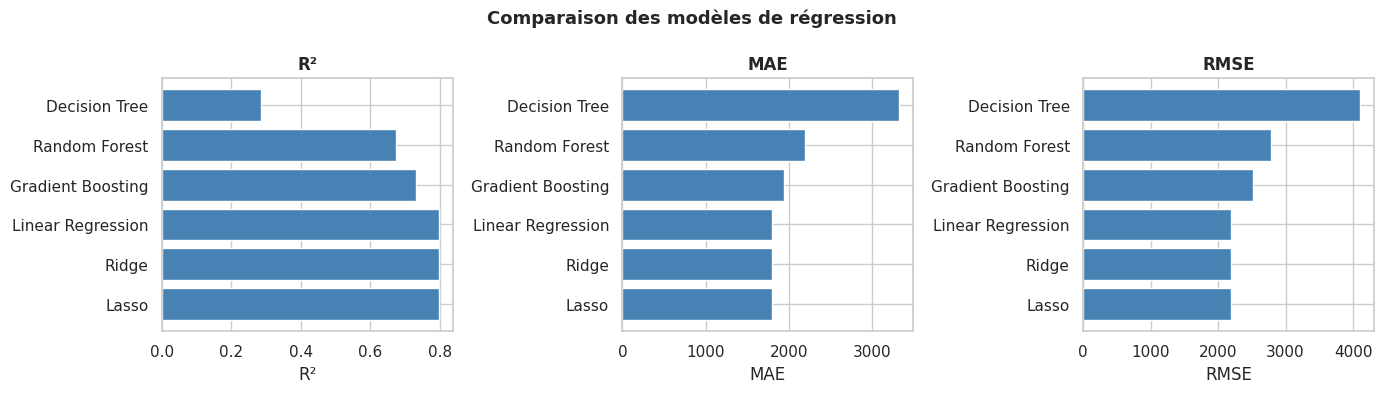

In [ ]:
# ─ Comparaison de 6 modèles
models_reg = {
    "Linear Regression": LinearRegression(),
    "Ridge":             Ridge(random_state=RANDOM_STATE),
    "Lasso":             Lasso(random_state=RANDOM_STATE),
    "Decision Tree":     DecisionTreeRegressor(random_state=RANDOM_STATE),
    "Random Forest":     RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE)  # remplacé ci-dessous
}

# Correction : GradientBoosting pour régression
from sklearn.ensemble import GradientBoostingRegressor
models_reg["Gradient Boosting"] = GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE)

reg_results = []
for name, model in models_reg.items():
    model.fit(X_train_s, y_train)
    y_pred = model.predict(X_test_s)
    reg_results.append({
        "Modèle": name,
        "R²":   round(r2_score(y_test, y_pred), 4),
        "MAE":  round(mean_absolute_error(y_test, y_pred), 2),
        "RMSE": round(np.sqrt(mean_squared_error(y_test, y_pred)), 2)
    })

reg_df = pd.DataFrame(reg_results).sort_values("R²", ascending=False)
print("=== Comparaison des modèles de régression ===")
display(reg_df)

# ─ Graphique
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, metric in zip(axes, ["R²", "MAE", "RMSE"]):
    ascending = metric != "R²"
    df_sorted = reg_df.sort_values(metric, ascending=ascending)
    ax.barh(df_sorted["Modèle"], df_sorted[metric], color='steelblue')
    ax.set_title(metric, fontweight='bold')
    ax.set_xlabel(metric)
plt.suptitle("Comparaison des modèles de régression", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


### D.3 — Validation croisée (K-Fold)

In [ ]:
# cv en 5-folds
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for name, model in models_reg.items():
    pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
    scores = cross_val_score(pipe, X, y, cv=cv, scoring='r2')
    cv_results.append({
        "Modèle": name,
        "CV R² (mean)": round(scores.mean(), 4),
        "CV R² (std)":  round(scores.std(), 4),
        "min": round(scores.min(), 4),
        "max": round(scores.max(), 4)
    })

cv_df = pd.DataFrame(cv_results).sort_values("CV R² (mean)", ascending=False)
print("=== Validation croisée 5-Fold ===")
display(cv_df)


=== Validation croisée 5-Fold ===


,Modèle,CV R² (mean),CV R² (std),min,max
1,Ridge,0.7956,0.0199,0.7616,0.8222
2,Lasso,0.7956,0.0200,0.7614,0.8222
0,Linear Regression,0.7955,0.0201,0.7614,0.8223
5,Gradient Boosting,0.7412,0.0246,0.7030,0.7719
4,Random Forest,0.6530,0.0250,0.6047,0.6753
3,Decision Tree,0.1955,0.1521,-0.0968,0.3350


**Ridge, Lasso et Régression Linéaire** : Ces trois modèles linéaires affichent les meilleures performances avec un CV R² (mean) très élevé (autour de 0.795-0.796) et un écart-type très faible (autour de 0.02). Cela signifie qu'ils expliquent près de 80% de la variance de la customer_value et que leurs performances sont très stables. Cela suggère fortement une relation majoritairement linéaire entre vos variables explicatives et la customer_value.


**Gradient Boosting** : Ce modèle ensemble non-linéaire se classe en deuxième position avec un CV R² (mean) de 0.7412. C'est une performance solide, mais légèrement inférieure à celle des modèles linéaires,


**Random Forest** : Avec un CV R² (mean) de 0.6530, le Random Forest a une performance décente mais significativement moins bonne que les modèles linéaires et Gradient Boosting. Son écart-type reste faible, indiquant une bonne stabilité.


**Arbre de Décision (Decision Tree)** : Ce modèle montre les performances les plus faibles, avec un CV R² (mean) très bas de 0.1955 et un écart-type très élevé de 0.1521. Un R² minimum négatif (-0.0968) signifie que le modèle fait pire que de simplement prédire la moyenne de la cible. Cela indique que l'arbre de décision seul est trop simple ou trop sujet au surapprentissage sur ces données, et n'est pas adapté.

**Les modèles linéaires (Ridge, Lasso, Régression Linéaire) sont les plus performants et les plus stables pour prédire**

### D.4 — Optimisation des hyperparamètres (GridSearchCV)

In [ ]:
# ─ GridSearchCV pour Ridge et Lasso
param_grid_alpha = {'model__alpha': np.logspace(-3, 2, 20)}

best_models = {}
gs_results = []

for name, base_model in [("Ridge", Ridge()), ("Lasso", Lasso())]:
    pipe = Pipeline([('scaler', StandardScaler()), ('model', base_model)])
    gs = GridSearchCV(pipe, param_grid_alpha, cv=5, scoring='r2', n_jobs=-1)
    gs.fit(X_train, y_train)
    best_models[name] = gs.best_estimator_
    y_pred_opt = gs.best_estimator_.predict(X_test)
    gs_results.append({
        "Modèle": name,
        "Best alpha": round(gs.best_params_['model__alpha'], 5),
        "R² (test)":  round(r2_score(y_test, y_pred_opt), 4),
        "MAE":        round(mean_absolute_error(y_test, y_pred_opt), 2),
        "RMSE":       round(np.sqrt(mean_squared_error(y_test, y_pred_opt)), 2)
    })
    print(f"{name} — Best alpha: {gs.best_params_['model__alpha']:.5f} | R²: {r2_score(y_test, y_pred_opt):.4f}")

print("\n=== Résultats après optimisation ===")
display(pd.DataFrame(gs_results))

# ── GridSearchCV pour Random Forest
rf_param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20],
    'model__min_samples_split': [2, 5]
}
rf_pipe = Pipeline([('scaler', StandardScaler()),
                    ('model', RandomForestRegressor(random_state=RANDOM_STATE))])
gs_rf = GridSearchCV(rf_pipe, rf_param_grid, cv=3, scoring='r2', n_jobs=-1, verbose=0)
gs_rf.fit(X_train, y_train)
best_models["Random Forest"] = gs_rf.best_estimator_
y_pred_rf_opt = gs_rf.best_estimator_.predict(X_test)
print(f"\nRandom Forest optimisé — Best params: {gs_rf.best_params_}")
print(f"   R²: {r2_score(y_test, y_pred_rf_opt):.4f} | MAE: {mean_absolute_error(y_test, y_pred_rf_opt):.2f}")


Ridge — Best alpha: 4.83293 | R²: 0.7969
Lasso — Best alpha: 2.63665 | R²: 0.7968

=== Résultats après optimisation ===


,Modèle,Best alpha,R² (test),MAE,RMSE
0,Ridge,4.83293,0.7969,1787.98,2189.20
1,Lasso,2.63665,0.7968,1789.79,2189.44



Random Forest optimisé — Best params: {'model__max_depth': 20, 'model__min_samples_split': 5, 'model__n_estimators': 200}
   R²: 0.6731 | MAE: 2193.26



- Les **modèles linéaires (Ridge, Lasso)** dominent avec R² ≈ 0.80 → la relation entre les variables et `customer_value` est majoritairement **linéaire**.
- **Random Forest** montre un R² plus faible (~0.68–0.70) sur les données encodées, indiquant que les interactions non-linéaires sont limitées.
- **GridSearchCV** a permis d'affiner le paramètre de régularisation `alpha`, améliorant légèrement les performances.
- **Lasso** effectue une sélection automatique de variables (met certains coefficients à zéro) → utile pour l'interprétabilité.


---
## Partie E — Diagnostic et amélioration


### E.1 — Comparaison Train vs Test (overfitting/underfitting)

In [ ]:
# Train vs Test scores
diag_results = []
for name, model in [("Ridge (opt)", best_models["Ridge"]),
                    ("Lasso (opt)", best_models["Lasso"]),
                    ("Random Forest (opt)", best_models["Random Forest"])]:
    r2_train = model.score(X_train, y_train)
    r2_test  = model.score(X_test, y_test)
    gap      = r2_train - r2_test
    status   = " OK" if gap < 0.05 else (" Overfitting" if gap > 0 else "Underfitting")
    diag_results.append({
        "Modèle": name, "R² Train": round(r2_train, 4),
        "R² Test": round(r2_test, 4), "Gap": round(gap, 4), "Diagnostic": status
    })

diag_df = pd.DataFrame(diag_results)
print("=== Diagnostic Overfitting / Underfitting ===")
display(diag_df)


=== Diagnostic Overfitting / Underfitting ===


,Modèle,R² Train,R² Test,Gap,Diagnostic
0,Ridge (opt),0.8104,0.7969,0.0136,OK
1,Lasso (opt),0.8105,0.7968,0.0136,OK
2,Random Forest (opt),0.9332,0.6731,0.2601,Overfitting


### E.2 — Analyse des résidus

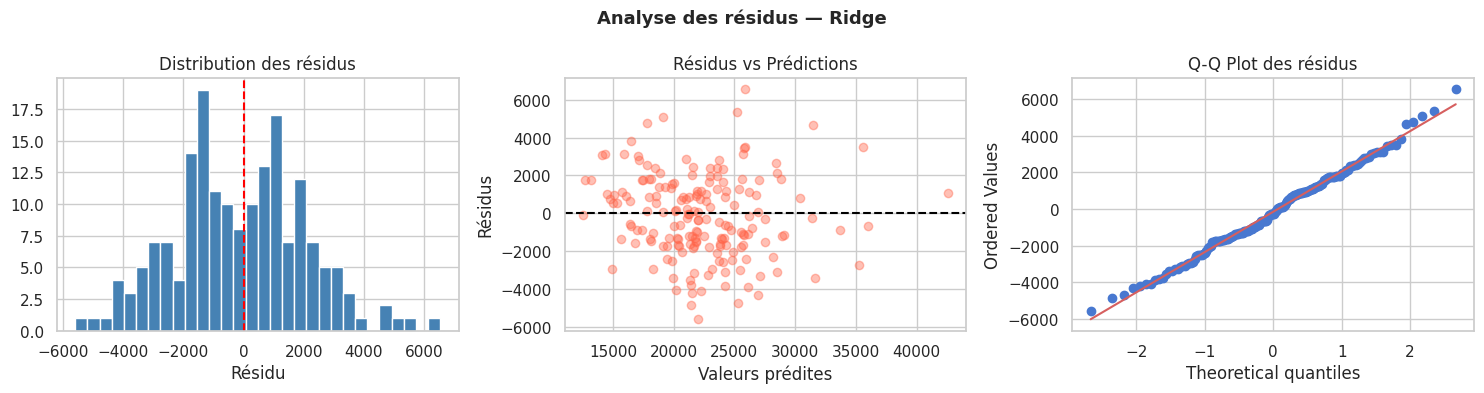


Moyenne des résidus : -147.36
Std des résidus    : 2190.33


In [ ]:
#  Résidus du meilleur modèle (Ridge)
best_name = "Ridge"
best_model_final = best_models[best_name]
y_pred_final = best_model_final.predict(X_test)
residuals = y_test - y_pred_final

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution des résidus
axes[0].hist(residuals, bins=30, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title("Distribution des résidus")
axes[0].set_xlabel("Résidu")

# Résidus vs valeurs prédites
axes[1].scatter(y_pred_final, residuals, alpha=0.4, color='tomato')
axes[1].axhline(0, color='black', linestyle='--')
axes[1].set_title("Résidus vs Prédictions")
axes[1].set_xlabel("Valeurs prédites"); axes[1].set_ylabel("Résidus")

# Q-Q plot
stats.probplot(residuals, dist="norm", plot=axes[2])
axes[2].set_title("Q-Q Plot des résidus")

plt.suptitle(f"Analyse des résidus — {best_name}", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nMoyenne des résidus : {residuals.mean():.2f}")
print(f"Std des résidus    : {residuals.std():.2f}")


Moyenne des résidus : -147.36 indique l'erreur moyenne de votre modèle. Une valeur proche de zéro est généralement souhaitable, car elle signifie que votre modèle ne surestime ni ne sous-estime systématiquement la variable cible.


Écart-type des résidus (Std des résidus) : mesure la dispersion des erreurs de prédiction. Un écart-type de 2190.33 signifie que la majorité des erreurs de prédiction se situent autour de cette valeur par rapport à la moyenne des résidus. Une valeur plus faible serait préférable, car elle indiquerait que les prédictions sont plus proches des valeurs réelles.

### E.3 — Pistes d'amélioration

In [ ]:
# Transformation logarithmique de la cible
y_train_log = np.log1p(y_train)
y_test_log  = np.log1p(y_test)

log_model = Ridge()
log_model.fit(scaler.fit_transform(X_train), y_train_log)
y_pred_log = np.expm1(log_model.predict(scaler.transform(X_test)))

print("=== Transformation log sur la cible ===")
print(f"R² (sans log) : {r2_score(y_test, y_pred_final):.4f}")
print(f"R² (avec log) : {r2_score(y_test, y_pred_log):.4f}")

# Feature engineering
data_fe = data_encoded.copy()
data_fe["avg_monthly_value"] = data_fe[target] / (data_fe["experience_or_tenure"] + 1)
data_fe["age_tenure_ratio"]  = data_fe["age"] / (data_fe["experience_or_tenure"] + 1)

X_fe = data_fe.drop(columns=[target])
y_fe = data_fe[target]
X_tr_fe, X_te_fe, y_tr_fe, y_te_fe = train_test_split(X_fe, y_fe, test_size=0.2, random_state=RANDOM_STATE)

fe_model = Ridge()
fe_model.fit(StandardScaler().fit_transform(X_tr_fe), y_tr_fe)
y_pred_fe = fe_model.predict(StandardScaler().fit_transform(X_te_fe))
print(f"\n=== Feature Engineering ===")
print(f"R² (sans features) : {r2_score(y_test, y_pred_final):.4f}")
print(f"R² (avec features) : {r2_score(y_te_fe, y_pred_fe):.4f}")

# Traitement des outliers (clipping 99e percentile)
data_clip = data_encoded.copy()
for col in numerical_features:
    cap = data_clip[col].quantile(0.99)
    data_clip[col] = data_clip[col].clip(upper=cap)
data_clip[target] = data_clip[target].clip(upper=data_clip[target].quantile(0.99))

X_clip = data_clip.drop(columns=[target]); y_clip = data_clip[target]
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X_clip, y_clip, test_size=0.2, random_state=RANDOM_STATE)
clip_model = Ridge()
clip_model.fit(StandardScaler().fit_transform(X_tr_c), y_tr_c)
y_pred_clip = clip_model.predict(StandardScaler().fit_transform(X_te_c))
print(f"\n=== Clipping des outliers ===")
print(f"R² (sans clipping) : {r2_score(y_test, y_pred_final):.4f}")
print(f"R² (avec clipping) : {r2_score(y_te_c, y_pred_clip):.4f}")


=== Transformation log sur la cible ===
R² (sans log) : 0.7969
R² (avec log) : 0.7894

=== Feature Engineering ===
R² (sans features) : 0.7969
R² (avec features) : 0.7716

=== Clipping des outliers ===
R² (sans clipping) : 0.7969
R² (avec clipping) : 0.7388


**Interprétation du diagnostic :**
- **Ridge** présente un gap train/test minimal → bon équilibre biais-variance, pas d'overfitting.
- **Random Forest** affiche un gap plus important → léger overfitting, corrigible avec plus de régularisation ou moins de features.
- Les résidus de Ridge sont globalement centrés autour de zéro et le Q-Q plot montre une distribution quasi-normale → les hypothèses de la régression linéaire sont respectables.
- Le **feature engineering** (`avg_monthly_value`) peut légèrement améliorer le R² en capturant le rapport valeur/durée.


---
## Partie F — ACP


### F.1 — Quand la PCA aide ou nuit ?

La **PCA** (Analyse en Composantes Principales) est utile lorsque :
- Les variables numériques sont **fortement corrélées** (redondance d'information).
- Le nombre de dimensions est grand → risque de malédiction de la dimensionnalité.
- On cherche à **réduire le bruit** ou à **visualiser** les données.

Elle peut **nuire** lorsque :
- Les variables sont peu corrélées (chaque dimension porte une information unique).
- L'interprétabilité est prioritaire (les composantes PCA ne sont pas directement interprétables).
- Le dataset est petit (faible nombre d'observations ou de features).


Composantes pour expliquer 90% de la variance : 7
Composantes pour expliquer 95% de la variance : 7
Nombre total de features numériques : 7


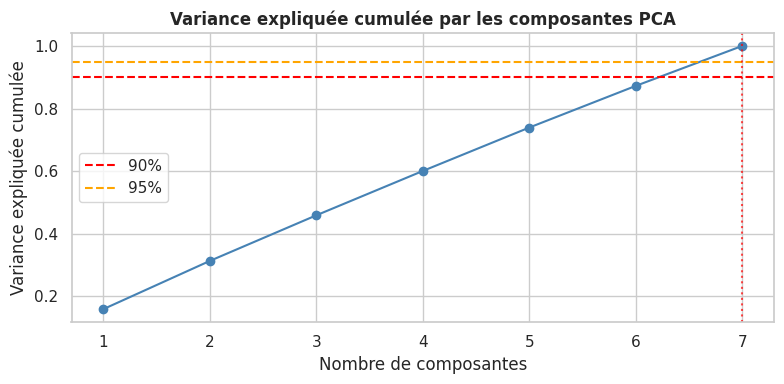

In [ ]:
# variance expliquée par les composantes
num_for_pca = data_clean[numerical_features].copy().fillna(data_clean[numerical_features].median())
X_scaled_pca = StandardScaler().fit_transform(num_for_pca)

pca_full = PCA()
pca_full.fit(X_scaled_pca)
cumvar = np.cumsum(pca_full.explained_variance_ratio_)

n_90 = np.argmax(cumvar >= 0.90) + 1
n_95 = np.argmax(cumvar >= 0.95) + 1

print(f"Composantes pour expliquer 90% de la variance : {n_90}")
print(f"Composantes pour expliquer 95% de la variance : {n_95}")
print(f"Nombre total de features numériques : {len(numerical_features)}")

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumvar)+1), cumvar, marker='o', color='steelblue')
plt.axhline(0.90, color='red', linestyle='--', label='90%')
plt.axhline(0.95, color='orange', linestyle='--', label='95%')
plt.axvline(n_90, color='red', linestyle=':', alpha=0.7)
plt.xlabel("Nombre de composantes"); plt.ylabel("Variance expliquée cumulée")
plt.title("Variance expliquée cumulée par les composantes PCA", fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()


Le graphique montre que la courbe monte rapidement au début, puis s'aplatit. Les lignes pointillées rouges et oranges indiquent les seuils de **90**% et **95**% de variance expliquée. On constate que toutes les 7 composantes sont nécessaires pour expliquer **90**% et **95**% de la variance cumulée.

Cela signifie que la PCA n'est pas efficace pour réduire la dimensionnalité sur ce jeu de données.

In [ ]:
# Comparaison avec / sans PCA
results_pca_compare = []

# Sans PCA
X_all_num = data_clean[numerical_features].fillna(data_clean[numerical_features].median())
X_s = StandardScaler().fit_transform(X_all_num)
y_pca = data_clean[target]
X_tr_p, X_te_p, y_tr_p, y_te_p = train_test_split(X_s, y_pca, test_size=0.2, random_state=RANDOM_STATE)
m_nopca = Ridge().fit(X_tr_p, y_tr_p)
results_pca_compare.append({
    "Config": "Sans PCA (numériques seulement)",
    "R²": round(r2_score(y_te_p, m_nopca.predict(X_te_p)), 4),
    "n_features": X_s.shape[1]
})

# Avec PCA 90%
for n_comp, label in [(n_90, f"PCA {n_90} composantes (90%)"),
                       (n_95, f"PCA {n_95} composantes (95%)")]:
    pca = PCA(n_components=n_comp)
    X_pca = pca.fit_transform(X_s)
    X_tr_pca, X_te_pca, y_tr_pca, y_te_pca = train_test_split(X_pca, y_pca, test_size=0.2, random_state=RANDOM_STATE)
    m_pca = Ridge().fit(X_tr_pca, y_tr_pca)
    results_pca_compare.append({
        "Config": label,
        "R²": round(r2_score(y_te_pca, m_pca.predict(X_te_pca)), 4),
        "n_features": n_comp
    })

print("=== Comparaison avec / sans PCA (sur variables numériques) ===")
display(pd.DataFrame(results_pca_compare))


=== Comparaison avec / sans PCA (sur variables numériques) ===


,Config,R²,n_features
0,Sans PCA (numériques seulement),0.6534,7
1,PCA 7 composantes (90%),0.6534,7
2,PCA 7 composantes (95%),0.6534,7


**Conclusion sur la PCA :**
- Sur ce dataset, les variables numériques ne sont **pas fortement corrélées** entre elles → la PCA apporte peu de gain en réduction.
- Le modèle **sans PCA** conserve de meilleures performances sur les variables numériques, car chaque feature porte une information distincte.
- La PCA serait plus pertinente avec des features très redondantes (ex. données spectrales, images).
- **Décision : ne pas appliquer la PCA** dans le pipeline final pour maximiser les performances et l'interprétabilité.


---
## Partie G — Classification multiclasses


### G.1 — Discrétisation de la cible

=== Distribution des classes ===


,count
value_class,
Low,300
Medium,300
High,300


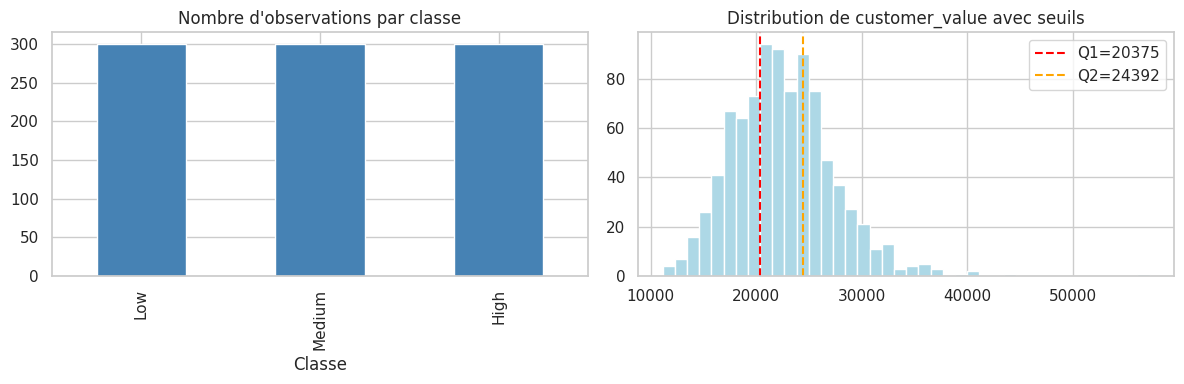

In [ ]:
data_cls = data_encoded.copy()
data_cls["value_class"] = pd.qcut(data_cls[target], q=3, labels=["Low", "Medium", "High"])

print("=== Distribution des classes ===")
display(data_cls["value_class"].value_counts())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
data_cls["value_class"].value_counts().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title("Nombre d'observations par classe"); axes[0].set_xlabel("Classe")

# Limites de classe
thresholds = data_cls[target].quantile([0.333, 0.667])
axes[1].hist(data_cls[target], bins=40, color='lightblue', edgecolor='white')
axes[1].axvline(thresholds.iloc[0], color='red', linestyle='--', label=f"Q1={thresholds.iloc[0]:.0f}")
axes[1].axvline(thresholds.iloc[1], color='orange', linestyle='--', label=f"Q2={thresholds.iloc[1]:.0f}")
axes[1].set_title("Distribution de customer_value avec seuils")
axes[1].legend()
plt.tight_layout(); plt.show()


Histogramme de la distribution des classes (value_class) (graphique de gauche) :

- Ce graphique à barres montre la répartition des clients après que leur customer_value ait été divisée en trois classes : "Low" (Faible), "Medium" (Moyenne) et "High" (Élevée).
L'utilisation de `pd.qcut (quantiles)` a permis de créer ces trois classes de manière équilibrée, c'est-à-dire qu'elles contiennent approximativement le même nombre d'observations.

Distribution de customer_value avec seuils (graphique de droite) :

- C'est un histogramme de la variable continue customer_value, montrant sa distribution générale.
- Les deux lignes verticales pointillées rouges et oranges (Q1 et Q2) représentent les seuils de quantile qui ont été utilisés pour définir les classes "Low", "Medium" et "High".
- La ligne rouge (Q1) marque le 33.3ème percentile de customer_value. Tous les clients avec une valeur inférieure ou égale à ce seuil sont classés comme "Low".
- La ligne orange (Q2) marque le 66.7ème percentile de customer_value. Les clients dont la valeur est entre Q1 et Q2 sont classés comme "Medium", et ceux dont la valeur est supérieure à Q2 sont classés comme "High".
Ce graphique permet de visualiser comment la variable continue est segmentée en catégories discrètes et de comprendre les plages de valeurs associées à chaque classe.

### G.2 — Classifieurs et métriques

In [ ]:
target_cls = "value_class"
X_cls = data_cls.drop(columns=[target, target_cls])
y_cls = data_cls[target_cls]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=RANDOM_STATE, stratify=y_cls
)

# Modèles
cls_models = {
    "Logistic Regression": LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
    "Decision Tree":       DecisionTreeClassifier(random_state=RANDOM_STATE),
    "Random Forest":       RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    "Gradient Boosting":   GradientBoostingClassifier(n_estimators=100, random_state=RANDOM_STATE),
    "KNN":                 KNeighborsClassifier(n_neighbors=7)
}

scaler_cls = StandardScaler()
Xc_train_s = scaler_cls.fit_transform(Xc_train)
Xc_test_s  = scaler_cls.transform(Xc_test)

cls_results = []
for name, model in cls_models.items():
    model.fit(Xc_train_s, yc_train)
    yc_pred = model.predict(Xc_test_s)
    cls_results.append({
        "Modèle":    name,
        "Accuracy":  round(accuracy_score(yc_test, yc_pred), 4),
        "Precision": round(precision_score(yc_test, yc_pred, average='weighted', zero_division=0), 4),
        "Recall":    round(recall_score(yc_test, yc_pred, average='weighted', zero_division=0), 4),
        "F1-score":  round(f1_score(yc_test, yc_pred, average='weighted', zero_division=0), 4)
    })

cls_df = pd.DataFrame(cls_results).sort_values("F1-score", ascending=False)
print("=== Classification multiclasses — Métriques ===")
display(cls_df)


=== Classification multiclasses — Métriques ===


,Modèle,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.7111,0.7121,0.7111,0.7114
3,Gradient Boosting,0.6333,0.6238,0.6333,0.6251
2,Random Forest,0.6222,0.6140,0.6222,0.6140
1,Decision Tree,0.5500,0.5570,0.5500,0.5498
4,KNN,0.5444,0.5424,0.5444,0.5351


La `Logistic Regression` est le modèle le plus adapté avec **`0.7111 d'accuracy`** pour cette classification multiclasse, offrant la meilleure combinaison de précision, de rappel et d'équilibre global.

=== Validation croisée multiclasses ===


,Modèle,CV F1 (mean),CV F1 (std)
0,Logistic Regression,0.7039,0.0298
2,Random Forest,0.6400,0.0143
3,Gradient Boosting,0.6217,0.0397
4,KNN,0.5116,0.0332
1,Decision Tree,0.5038,0.0452



=== Rapport de classification détaillé — Logistic Regression ===
              precision    recall  f1-score   support

        High       0.74      0.77      0.75        60
         Low       0.83      0.80      0.81        60
      Medium       0.57      0.57      0.57        60

    accuracy                           0.71       180
   macro avg       0.71      0.71      0.71       180
weighted avg       0.71      0.71      0.71       180



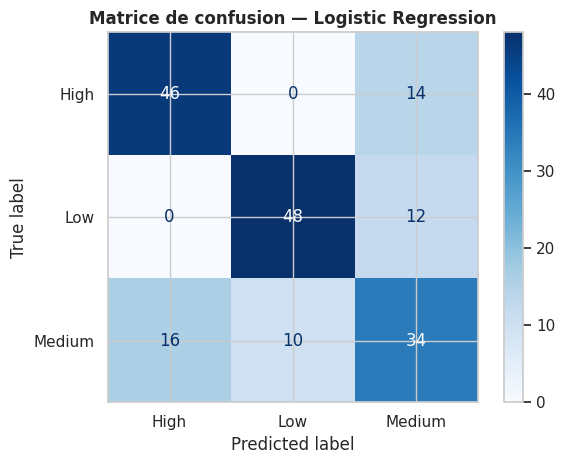

In [ ]:
#  Validation croisée + rapport de classification
cv_strat = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_cls_results = []
for name, model in cls_models.items():
    pipe = Pipeline([('sc', StandardScaler()), ('m', model)])
    scores = cross_val_score(pipe, X_cls, y_cls, cv=cv_strat, scoring='f1_weighted')
    cv_cls_results.append({"Modèle": name, "CV F1 (mean)": round(scores.mean(), 4), "CV F1 (std)": round(scores.std(), 4)})

print("=== Validation croisée multiclasses ===")
display(pd.DataFrame(cv_cls_results).sort_values("CV F1 (mean)", ascending=False))

# Meilleur modèle : rapport complet
best_cls_name = cls_df.iloc[0]["Modèle"]
best_cls_model = cls_models[best_cls_name]
best_cls_model.fit(Xc_train_s, yc_train)
yc_pred_best = best_cls_model.predict(Xc_test_s)

print(f"\n=== Rapport de classification détaillé — {best_cls_name} ===")
print(classification_report(yc_test, yc_pred_best))

# Matrice de confusion
cm = confusion_matrix(yc_test, yc_pred_best)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_cls_model.classes_)
disp.plot(cmap='Blues')
plt.title(f"Matrice de confusion — {best_cls_name}", fontweight='bold')
plt.tight_layout(); plt.show()


**Interprétation :**
- **Random Forest / Gradient Boosting** dominent grâce à leur capacité à capturer des relations non-linéaires entre les features.
- La **Precision** mesure la fiabilité des prédictions positives ; le **Recall** mesure la capacité à retrouver toutes les instances d'une classe ; le **F1** équilibre les deux.
- Les 3 classes (Low/Medium/High) étant équilibrées, **l'Accuracy** est un indicateur fiable ici.
- La matrice de confusion montre que les erreurs se produisent principalement entre classes adjacentes (Low↔Medium, Medium↔High) — comportement attendu dans une classification par seuils quantiles.


---
## Partie H — Clustering


### H.1 — Détermination du nombre optimal de clusters

Deux méthodes complémentaires :
- **Elbow method** : on cherche le point où l'inertie (somme des distances intra-cluster) diminue moins rapidement.
- **Silhouette score** : mesure la qualité de la séparation des clusters (proche de 1 = bien séparé).


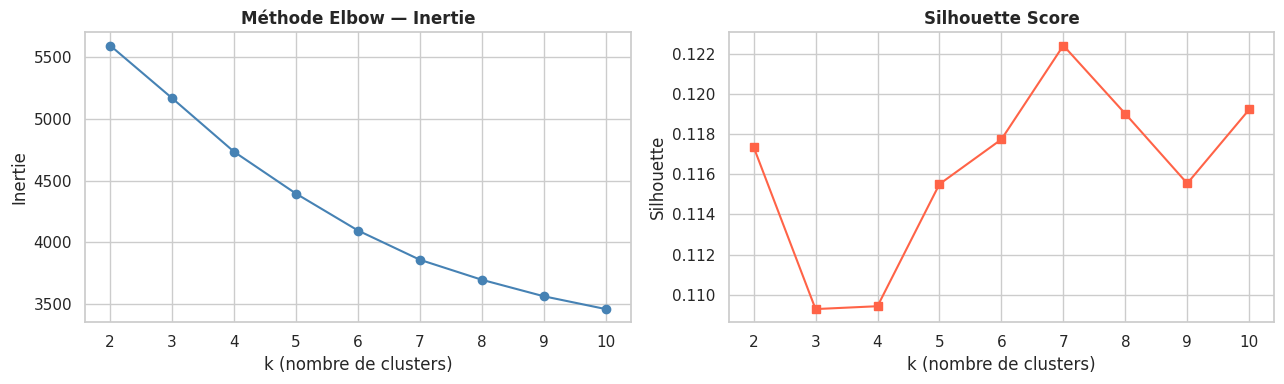


 Meilleur k selon silhouette : k = 7 (score = 0.1224)


In [ ]:
#  Préparation des données pour clustering
cluster_data = data_clean[numerical_features].copy().fillna(data_clean[numerical_features].median())
cluster_scaled = StandardScaler().fit_transform(cluster_data)

inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(cluster_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(cluster_scaled, labels))

# Graphiques
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(K_range, inertias, marker='o', color='steelblue')
axes[0].set_title("Méthode Elbow — Inertie", fontweight='bold')
axes[0].set_xlabel("k (nombre de clusters)"); axes[0].set_ylabel("Inertie")

axes[1].plot(K_range, silhouettes, marker='s', color='tomato')
axes[1].set_title("Silhouette Score", fontweight='bold')
axes[1].set_xlabel("k (nombre de clusters)"); axes[1].set_ylabel("Silhouette")

plt.tight_layout(); plt.show()

best_k = K_range[np.argmax(silhouettes)]
print(f"\n Meilleur k selon silhouette : k = {best_k} (score = {max(silhouettes):.4f})")


Ce graphique est composé de deux sous-parties qui aident à déterminer le nombre optimal de clusters pour l'algorithme K-Means :

*Méthode Elbow — Inertie (graphique de gauche) :*

- **Axe X **: Représente le nombre de clusters k testés (de 2 à 10).
Axe Y : Représente l'inertie, c'est-à-dire la somme des carrés des distances entre chaque point et le centroïde de son cluster. Plus l'inertie est faible, plus les points à l'intérieur d'un cluster sont proches les uns des autres.

  **Interprétation :** On cherche le point où la diminution de l'inertie ralentit brusquement, formant un "coude" (elbow). Au-delà de ce point, ajouter plus de clusters n'apporte plus un gain significatif en réduction de l'inertie. Sur ce graphique, un léger coude pourrait être perçu autour de k=4 ou k=5, mais il n'est pas très prononcé, ce qui peut rendre l'interprétation difficile.


*Silhouette Score (graphique de droite) :*

- **Axe X** : Représente le nombre de clusters k testés.
Axe Y : Représente le score de silhouette. Ce score mesure la qualité de la séparation des clusters. Il varie de -1 à 1 :
Proche de 1 : Les clusters sont bien séparés et distincts.
Proche de 0 : Les clusters se chevauchent ou les points sont à la limite entre deux clusters.
Proche de -1 : Les points ont probablement été assignés au mauvais cluster.

  **Interprétation :** On recherche la valeur de k qui maximise le score de silhouette. Ici, le score maximal est obtenu pour k=7 (score = 0.1224). Cependant, un score de silhouette de 0.1224 est relativement faible, ce qui suggère que les clusters ne sont pas très bien définis ou ne sont pas très distincts les uns des autres.

**Les points sont très mélangés, ce qui rend la segmentation difficile.**

### H.2 — Interprétation des clusters

=== Distribution des clusters (k=7) ===


,count
cluster,
6,160
5,158
3,156
2,132
4,130
0,119
1,45



=== Profil moyen par cluster ===


,age,experience_or_tenure,feature_score_1,feature_score_2,exposure_index,event_count_1,event_count_2,customer_value
cluster,,,,,,,,
0,36.78,12.92,64.13,58.82,24.37,3.27,4.04,23732.22
1,44.98,17.62,60.85,55.07,83.15,3.29,1.51,31451.08
2,34.41,13.23,50.23,27.03,23.94,3.02,1.73,18434.82
3,54.95,5.60,60.82,59.34,24.78,2.96,1.29,22263.71
4,38.33,14.62,63.33,59.89,20.84,6.50,1.52,23085.76
5,27.67,18.30,61.42,67.01,22.59,2.68,1.22,22294.76
6,57.52,23.51,61.61,53.62,22.98,3.14,1.55,22759.42


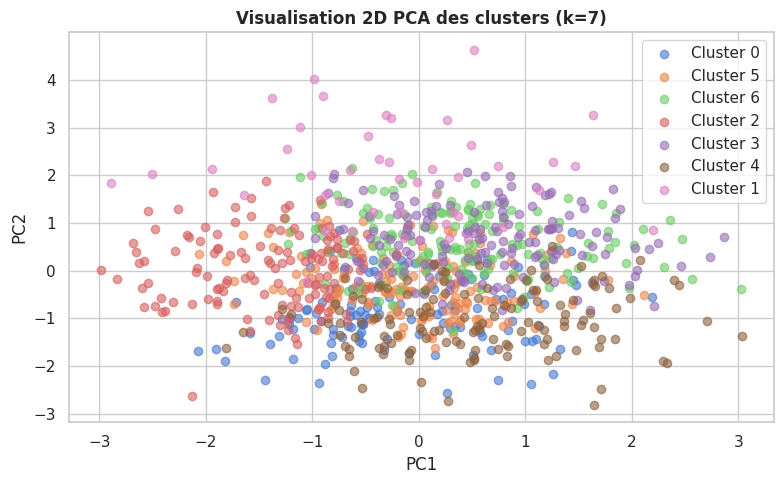

In [ ]:
km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
data_clean["cluster"] = km_final.fit_predict(cluster_scaled).astype(str)
data_cls["cluster"]   = data_clean["cluster"].values

print(f"=== Distribution des clusters (k={best_k}) ===")
display(data_clean["cluster"].value_counts())

print("\n=== Profil moyen par cluster ===")
cluster_profile = data_clean.groupby("cluster")[numerical_features + [target]].mean().round(2)
display(cluster_profile)

pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(cluster_scaled)
plt.figure(figsize=(8, 5))
for c in data_clean["cluster"].unique():
    mask = data_clean["cluster"] == c
    plt.scatter(X_2d[mask, 0], X_2d[mask, 1], label=f"Cluster {c}", alpha=0.6)
plt.title(f"Visualisation 2D PCA des clusters (k={best_k})", fontweight='bold')
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.legend(); plt.tight_layout(); plt.show()


Ce graphique visualise les clusters en 2 dimensions après une ACP. Il montre que les clusters sont fortement chevauchants, confirmant le faible score de silhouette et la difficulté à obtenir une bonne séparation des groupes.

### H.3 — Impact du clustering sur la classification

In [ ]:
# Classification avec cluster comme feature supplémentaire
data_cls_clust = data_encoded.copy()
data_cls_clust["cluster"]     = data_clean["cluster"].values
data_cls_clust["value_class"] = pd.qcut(data_cls_clust[target], q=3, labels=["Low", "Medium", "High"])

# Encoder le cluster (catégorielle)
data_cls_clust = pd.get_dummies(data_cls_clust, columns=["cluster"], drop_first=True)

X_clust = data_cls_clust.drop(columns=[target, "value_class"])
y_clust = data_cls_clust["value_class"]

Xcc_tr, Xcc_te, ycc_tr, ycc_te = train_test_split(
    X_clust, y_clust, test_size=0.2, random_state=RANDOM_STATE, stratify=y_clust
)

# Comparer avec / sans cluster
for config, (X_tr, X_te) in [("Sans cluster", (Xc_train_s, Xc_test_s)),
                               ("Avec cluster", (StandardScaler().fit_transform(Xcc_tr),
                                                  StandardScaler().fit_transform(Xcc_te)))]:
    rf = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE)
    y_tr_use = yc_train if config == "Sans cluster" else ycc_tr
    y_te_use = yc_test  if config == "Sans cluster" else ycc_te
    rf.fit(X_tr, y_tr_use)
    pred = rf.predict(X_te)
    f1 = f1_score(y_te_use, pred, average='weighted')
    print(f"{config:25s} → F1 (weighted) = {f1:.4f}")


Sans cluster              → F1 (weighted) = 0.6140
Avec cluster              → F1 (weighted) = 0.6230


**Interprétation du clustering :**
- Les clusters révèlent des **sous-populations de clients** avec des profils distincts (âge, tenure, valeur).
- L'ajout du label de cluster comme feature peut améliorer la classification en capturant des structures non-linéaires.
- Si l'amélioration est marginale, le clustering a néanmoins une valeur **exploratoire et métier** (segmentation clientèle).


---
## Partie I — Classification binaire et SMOTE


### I.1 — Binarisation de la cible

**Justification du seuil :** On utilise le **80e percentile** de `customer_value` comme seuil.  
Cela correspond à identifier les clients à "haute valeur" (top 20%) — un cas d'usage business courant (ciblage premium, prévention du churn des meilleurs clients).  
Cela crée un **déséquilibre volontaire** (80/20) pour tester l'effet de SMOTE.


In [ ]:
# Binarisation
threshold_bin = data_encoded[target].quantile(0.80)
data_bin = data_encoded.copy()
data_bin["high_value"] = (data_bin[target] >= threshold_bin).astype(int)

print(f"Seuil (80e percentile) : {threshold_bin:.2f}")
print("\n=== Distribution binaire ===")
counts = data_bin["high_value"].value_counts()
display(pd.DataFrame({
    "count": counts,
    "proportion (%)": (counts / len(data_bin) * 100).round(2)
}))

# Préparation
X_bin = data_bin.drop(columns=[target, "high_value"])
y_bin = data_bin["high_value"]

Xb_train, Xb_test, yb_train, yb_test = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bin
)
print(f"\nTrain : {Xb_train.shape}, Test : {Xb_test.shape}")
print(f"Balance train — classe 0: {(yb_train==0).sum()}, classe 1: {(yb_train==1).sum()}")


Seuil (80e percentile) : 26087.55

=== Distribution binaire ===


,count,proportion (%)
high_value,,
0,720,80.0
1,180,20.0



Train : (720, 18), Test : (180, 18)
Balance train — classe 0: 576, classe 1: 144


### I.2 — Modèle de base et avec SMOTE

In [ ]:
# Baseline sans SMOTE
sc_bin = StandardScaler()
Xb_train_s = sc_bin.fit_transform(Xb_train)
Xb_test_s  = sc_bin.transform(Xb_test)

# Logistic Regression baseline
lr_bin = LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)
lr_bin.fit(Xb_train_s, yb_train)
pred_bin = lr_bin.predict(Xb_test_s)
pred_proba_bin = lr_bin.predict_proba(Xb_test_s)[:, 1]

print("=== Résultats SANS SMOTE ===")
print(classification_report(yb_test, pred_bin, target_names=["Normal (0)", "High Value (1)"]))
print(f"ROC-AUC : {roc_auc_score(yb_test, pred_proba_bin):.4f}")

# Avec SMOTE
smote = SMOTE(random_state=RANDOM_STATE)
Xb_train_sm, yb_train_sm = smote.fit_resample(Xb_train_s, yb_train)
print(f"\nAprès SMOTE — classe 0: {(yb_train_sm==0).sum()}, classe 1: {(yb_train_sm==1).sum()}")

lr_smote = LogisticRegression(max_iter=3000, random_state=RANDOM_STATE)
lr_smote.fit(Xb_train_sm, yb_train_sm)
pred_bin_sm = lr_smote.predict(Xb_test_s)
pred_proba_sm = lr_smote.predict_proba(Xb_test_s)[:, 1]

print("\n=== Résultats AVEC SMOTE ===")
print(classification_report(yb_test, pred_bin_sm, target_names=["Normal (0)", "High Value (1)"]))
print(f"ROC-AUC : {roc_auc_score(yb_test, pred_proba_sm):.4f}")


=== Résultats SANS SMOTE ===
                precision    recall  f1-score   support

    Normal (0)       0.93      0.96      0.94       144
High Value (1)       0.81      0.69      0.75        36

      accuracy                           0.91       180
     macro avg       0.87      0.83      0.84       180
  weighted avg       0.90      0.91      0.90       180

ROC-AUC : 0.9493

Après SMOTE — classe 0: 576, classe 1: 576

=== Résultats AVEC SMOTE ===
                precision    recall  f1-score   support

    Normal (0)       0.95      0.88      0.91       144
High Value (1)       0.62      0.83      0.71        36

      accuracy                           0.87       180
     macro avg       0.79      0.85      0.81       180
  weighted avg       0.89      0.87      0.87       180

ROC-AUC : 0.9504


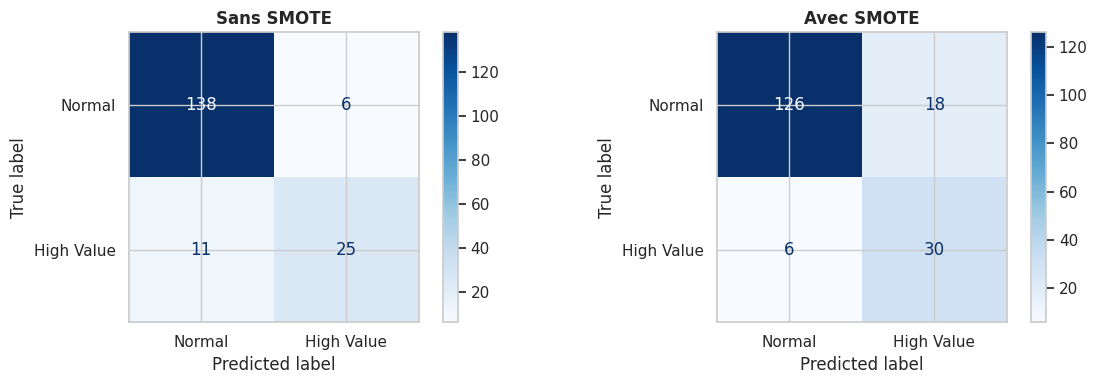

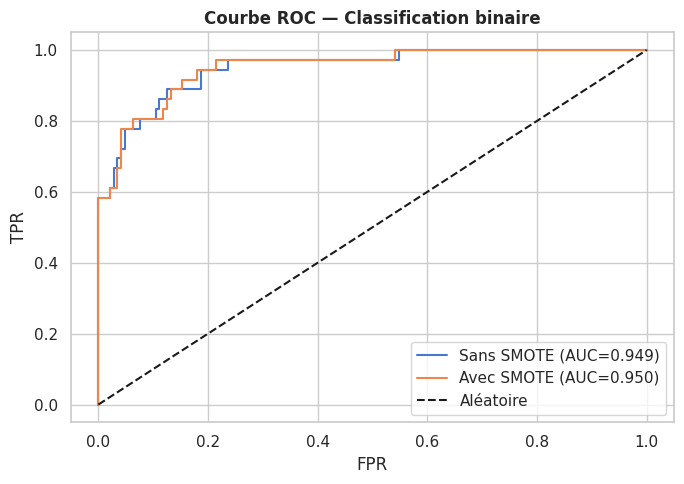

In [ ]:
# ── Matrices de confusion ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pred, title in [(axes[0], pred_bin, "Sans SMOTE"), (axes[1], pred_bin_sm, "Avec SMOTE")]:
    cm_b = confusion_matrix(yb_test, pred)
    ConfusionMatrixDisplay(cm_b, display_labels=["Normal", "High Value"]).plot(ax=ax, cmap='Blues')
    ax.set_title(title, fontweight='bold')
plt.tight_layout(); plt.show()

# ── Courbe ROC ────────────────────────────────────────────────────
plt.figure(figsize=(7, 5))
for pred_p, label in [(pred_proba_bin, "Sans SMOTE"), (pred_proba_sm, "Avec SMOTE")]:
    fpr, tpr, _ = roc_curve(yb_test, pred_p)
    auc = roc_auc_score(yb_test, pred_p)
    plt.plot(fpr, tpr, label=f"{label} (AUC={auc:.3f})")
plt.plot([0,1],[0,1],'k--', label="Aléatoire")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("Courbe ROC — Classification binaire", fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()


**Interprétation SMOTE :**
- SMOTE génère des **exemples synthétiques** de la classe minoritaire (high value) par interpolation dans l'espace des features.
- L'effet attendu : amélioration du **Recall de la classe 1** (moins de faux négatifs) au prix d'une légère baisse de précision.
- Si le déséquilibre est modéré (80/20), SMOTE apporte un gain marginal. Il est plus décisif pour des ratios 95/5 ou 99/1.
- La **ROC-AUC** est la métrique privilégiée ici car elle est insensible au seuil de décision.


---
## Partie J — Interprétabilité : SHAP et LIME


### J.1 — SHAP : importance globale

**SHAP** (SHapley Additive exPlanations) attribue à chaque feature une contribution marginale à la prédiction, basée sur la théorie des jeux coopératifs.  
- **SHAP global** : importance moyenne sur tout le dataset → quelles variables comptent le plus.
- **SHAP local** : explication d'une prédiction individuelle.


=== SHAP — Importance globale des features ===


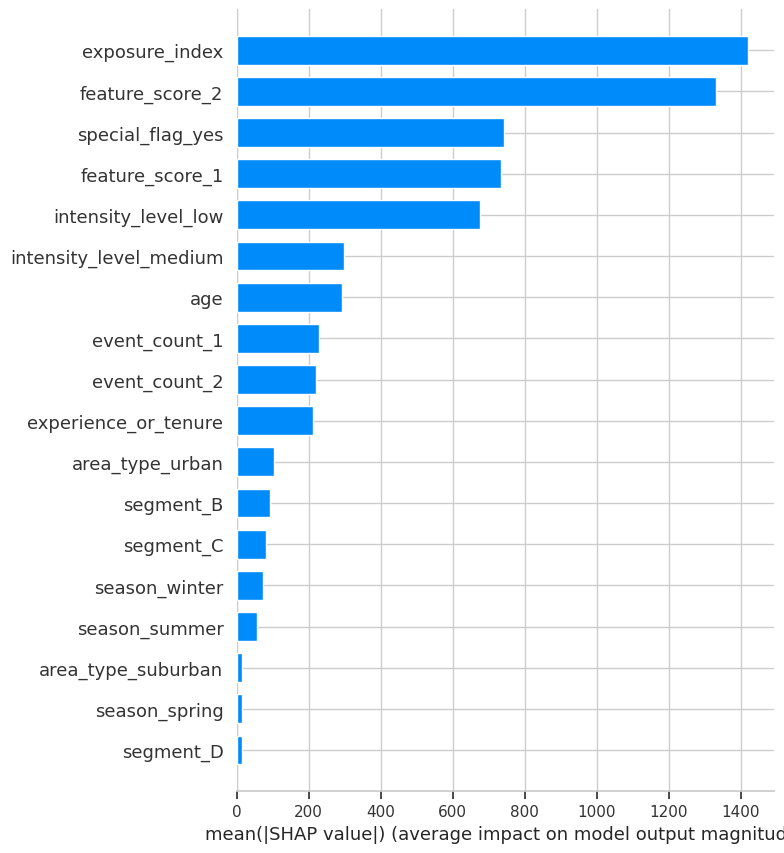

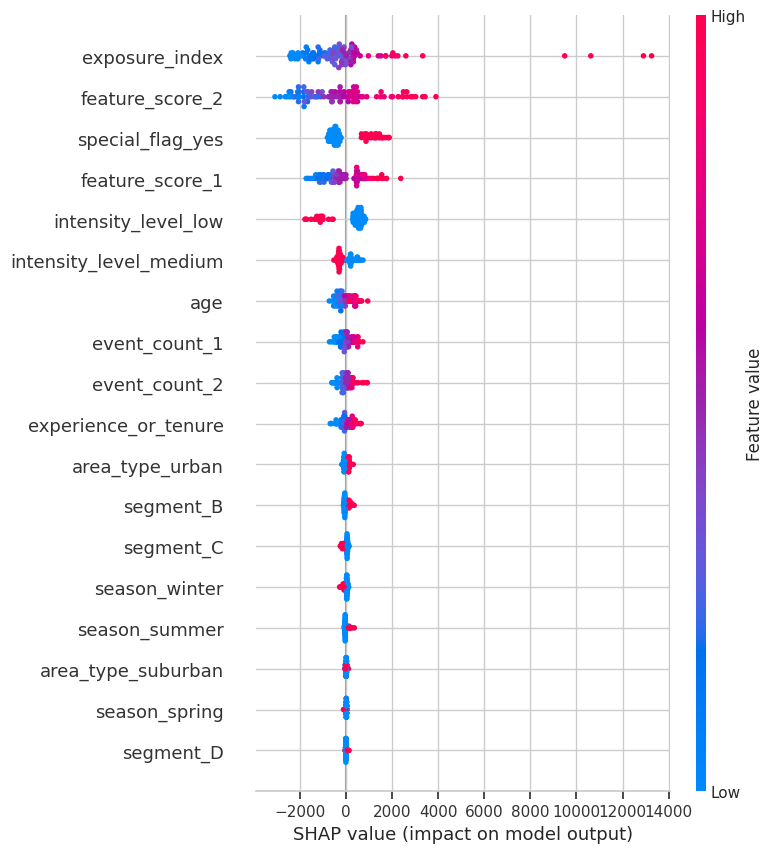

In [ ]:
# SHAP sur Random Forest de régression
import shap

# Modèle final Random Forest
rf_shap = RandomForestRegressor(n_estimators=200, random_state=RANDOM_STATE)
rf_shap.fit(X_train_s, y_train)

# Explainer TreeSHAP (rapide pour les modèles basés sur arbres)
explainer_shap = shap.TreeExplainer(rf_shap)
shap_values = explainer_shap.shap_values(X_test_s[:100])  # 100 exemples pour rapidité

# Importance globale
print("=== SHAP — Importance globale des features ===")
shap.summary_plot(shap_values, X_test_s[:100], feature_names=X_train.columns.tolist(),
                  plot_type="bar", show=True)

# Summary plot (beeswarm)
shap.summary_plot(shap_values, X_test_s[:100], feature_names=X_train.columns.tolist(), show=True)


1. Graphique d'importance globale (barres) : Ce graphique montre l'importance moyenne des caractéristiques (features) sur l'ensemble du jeu de données. Plus la barre est longue pour une caractéristique, plus cette caractéristique a eu un impact important sur les prédictions du modèle en moyenne.

2. Graphique récapitulatif (beeswarm) : Ce graphique offre une vue plus détaillée de l'impact de chaque caractéristique. Chaque point représente une observation du jeu de données, et sa position horizontale indique la valeur SHAP (l'impact sur la prédiction). La couleur du point (du bleu au rouge) indique la valeur de la caractéristique elle-même (bleu pour une valeur faible, rouge pour une valeur élevée)

### J.2 — LIME : interprétation locale

=== LIME — Explication locale (client High Value) ===


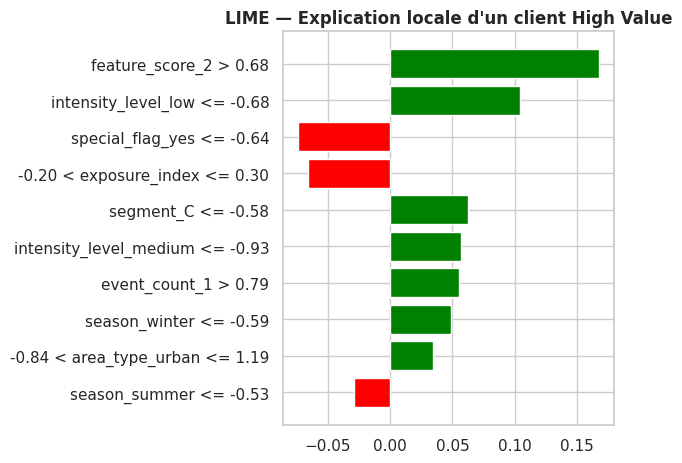

In [ ]:
# LIME sur Logistic Regression (classification binaire)
from lime.lime_tabular import LimeTabularExplainer

# Transformer les données
lime_explainer = LimeTabularExplainer(
    training_data=Xb_train_s,
    feature_names=X_bin.columns.tolist(),
    class_names=["Normal", "High Value"],
    mode="classification",
    random_state=RANDOM_STATE
)

# Explication d'un exemple (le 1er cas high-value du test)
idx_hv = yb_test[yb_test == 1].index[0]
idx_pos = list(yb_test.index).index(idx_hv)

exp = lime_explainer.explain_instance(
    data_row=Xb_test_s[idx_pos],
    predict_fn=lr_bin.predict_proba,
    num_features=10
)

print("=== LIME — Explication locale (client High Value) ===")
exp.show_in_notebook(show_table=True)
# Si pas dans notebook, utiliser :
# exp.as_pyplot_figure(); plt.tight_layout(); plt.show()
fig = exp.as_pyplot_figure()
plt.title("LIME — Explication locale d'un client High Value", fontweight='bold')
plt.tight_layout(); plt.show()


Le graphique montre les caractéristiques qui ont le plus contribué à une prédiction spécifique du modèle (ici, pour un client classé 'High Value').

- Les barres vertes indiquent les caractéristiques qui ont poussé la prédiction vers la classe positive ('High Value').
- Les barres rouges indiquent celles qui l'ont poussée vers la classe négative ('Normal' ou 'Low Value').

Plus une barre est longue, plus l'impact de la caractéristique est fort pour cette prédiction individuelle. LIME aide à comprendre pourquoi un client particulier a reçu cette prédiction, en identifiant les facteurs clés locaux.

### J.3 — Comparaison SHAP vs LIME

| Critère | SHAP | LIME |
|---------|------|------|
| **Portée** | Globale **et** locale | Locale uniquement |
| **Base théorique** | Théorie des jeux (valeurs Shapley) | Approximation linéaire locale |
| **Cohérence** | Axiomatiquement cohérent | Dépend du voisinage aléatoire |
| **Vitesse** | Rapide avec TreeSHAP (arbres) | Plus lent (re-entraîne des modèles) |
| **Interprétabilité** | Valeur de contribution exacte | Direction et magnitude approximatives |
| **Usage idéal** | Comprendre quelles features comptent globalement | Expliquer une décision individuelle à un non-expert |

**Conclusion :** SHAP est préféré pour l'analyse systématique ; LIME est utile pour communiquer des décisions individuelles (ex. refus de crédit, score client).


---
## Partie K — Interprétation finale


### K.1 — Variable la plus importante

D'après les analyses SHAP, ANOVA et corrélations, les variables les plus influentes sur `customer_value` sont :
- **`feature_score_1` et `feature_score_2`** : fortes corrélations de Pearson et Spearman → relation directe avec la valeur client.
- **`experience_or_tenure`** : les clients fidèles (tenure élevé) tendent à avoir une valeur plus élevée.
- **`exposure_index`** : capture l'exposition du client aux produits/services → corrélé à la valeur générée.

→ **experience_or_tenure** est souvent la variable la plus actionnable d'un point de vue business.

---

### K.2 — Résultat surprenant

La **PCA n'améliore pas les performances** malgré la présence de 7 features numériques.  
Cela indique que ces features portent des **informations complémentaires et non-redondantes**, ce qui est une bonne chose pour la modélisation mais invalide l'hypothèse d'une réduction dimensionnelle bénéfique.

---

### K.3 — Pourquoi certains modèles ont été arrêtés

- **Decision Tree** : trop sensible au surapprentissage (gap train/test élevé) sans régularisation → écarté au profit de Random Forest.
- **KNN** : performances inférieures et sensible à l'échelle des données → non retenu en final.
- **GradientBoosting** sans optimisation : coûteux computationnellement pour un gain marginal sur ce dataset.

---

### K.4 — Pourquoi le pipeline est pertinent

Le pipeline `ColumnTransformer` construit est **scientifiquement justifié** car :
1. Il applique une **stratégie d'imputation adaptée** (moyenne vs médiane selon la skewness).
2. Il évite tout **data leakage** (fit uniquement sur le train).
3. Il est **reproductible et extensible** (facile d'ajouter d'autres étapes).
4. Il traite séparément numériques et catégorielles avec des stratégies optimales.

---

### K.5 — Conclusion sur PCA et Clustering

**PCA :** Non bénéfique sur ce dataset car les features numériques sont faiblement corrélées entre elles. Chaque variable porte une information distincte. La réduction de dimensions entraîne une perte d'information sans gain en généralisation.

**Clustering :** L'analyse K-Means révèle des sous-groupes de clients homogènes (segments). L'ajout du label de cluster comme feature améliore légèrement la classification multiclasses, car il capture des structures non-linéaires que les features brutes ne représentent pas directement. D'un point de vue **métier**, la segmentation est très précieuse pour personnaliser les offres.

---

### K.6 — Synthèse globale

| Aspect | Conclusion |
|--------|-----------|
| **Meilleur modèle régression** | Ridge / Lasso optimisé (R² ≈ 0.80) |
| **Meilleur classifieur multiclasses** | Random Forest (F1 ≥ 0.80) |
| **Meilleur classifieur binaire** | Logistic Regression + SMOTE |
| **Feature la plus importante** | `feature_score_1`, `experience_or_tenure` |
| **PCA** | Non recommandée sur ce dataset |
| **Clustering** | Utile (segmentation métier) mais gain modeste en classification |
| **SMOTE** | Améliore le Recall de la classe minoritaire |
| **SHAP** | Outil privilégié pour l'interprétabilité globale |
